- feature extraction and feature engineering: transformation of raw data into features suitable for modeling;

- feature transformation: transformation of data to improve the accuracy of the algorithm;

- feature selection: removing unnecessary features.

###  predict the popularity of a new rental listing, i.e., classify the listing into three classes: ['low', 'medium' , 'high'].

In [2]:
# preload the dataset automatically if not in place

import os
from pathlib import Path
from pprint import pprint
import numpy as np
import pandas as pd

def check_file_exists(filename, outpath: Path, overwrite=False):
    file_exists = os.path.exists(f'{outpath}/{filename}')

    if(file_exists):
        print("file found in location")
    else:
        print("file missing")

In [3]:
FILE_NAME = "renthop_train.json.gz"
DATA_PATH = Path("./")

check_file_exists(filename=FILE_NAME, outpath=DATA_PATH)

file found in location


In [4]:
df = pd.read_json(DATA_PATH / FILE_NAME, compression="gzip", convert_dates=["created"])
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


**bag of words** - we create a vector with the length of the vocabulary, compute the number of occurrences of each word in the text, and place that number of occurrences in the appropriate position in the vector.

In [5]:
# enumerate adds indexes

fruits = ["apple", "banana", "orange"]

result = list(enumerate(fruits))
print(result)

[(0, 'apple'), (1, 'banana'), (2, 'orange')]


In [6]:
texts = ["i have a cat", "you have a dog", "you and i have a cat and a dog"]

vocabulary = list(
    enumerate(set([word for sentence in texts for word in sentence.split()]))
)

print("vocabulary", vocabulary)

def vectorizer(text):
    vector = np.zeros(len(vocabulary))
    for i, word in vocabulary:
        num = 0
        for w in text:
            if w == word:
                num += 1
        if num:
            vector[i] = num
    return vector

print("Vectors:")
for sentence in texts:
    print(vectorizer(sentence.split()))

vocabulary [(0, 'i'), (1, 'have'), (2, 'cat'), (3, 'and'), (4, 'a'), (5, 'dog'), (6, 'you')]
Vectors:
[1. 1. 1. 0. 1. 0. 0.]
[0. 1. 0. 0. 1. 1. 1.]
[1. 1. 1. 2. 2. 1. 1.]


When using algorithms like Bag of Words, we lose the order of the words in the text, which means that the texts “i have no cows” and “no, i have cows” will appear identical after vectorization when, in fact, they have the opposite meaning. To avoid this problem, we can revisit our tokenization step and use N-grams (the sequence of N consecutive tokens) instead.

Great question. The key thing you're missing is **what `CountVectorizer` considers to be the vocabulary**.

Let's go through it step by step.

### Step 1: The documents

```python
doc1 = "no i have cows"
doc2 = "i have no cows"
```

---

### Step 2: Build the vocabulary

Since `ngram_range=(1,1)`, we only look at **individual words**.

Across both documents, the unique words are:

```text
no
i
have
cows
```

`CountVectorizer` sorts them alphabetically by default:

```python
['cows', 'have', 'no']
```

Wait...where did **"i"** go?

### Step 3: Why is "i" missing?

By default, `CountVectorizer` uses the regular expression

```python
token_pattern=r"(?u)\b\w\w+\b"
```

This means:

> Only keep tokens that are **2 or more characters long**.

Since `"i"` is only **one character**, it is **ignored**.

So the vocabulary becomes:

| Index | Word |
| ----: | ---- |
|     0 | cows |
|     1 | have |
|     2 | no   |

You can verify this:

```python
vect = CountVectorizer()

vect.fit(["no i have cows", "i have no cows"])

print(vect.vocabulary_)
```

Output:

```python
{'cows': 0, 'have': 1, 'no': 2}
```

---

### Step 4: Count the words

Document 1:

```text
no i have cows
```

Ignoring `"i"`:

```text
no
have
cows
```

Counts:

| Word | Count |
| ---- | ----: |
| cows |     1 |
| have |     1 |
| no   |     1 |

Vector:

```python
[1, 1, 1]
```

---

Document 2:

```text
i have no cows
```

Ignoring `"i"`:

```text
have
no
cows
```

Counts:

| Word | Count |
| ---- | ----: |
| cows |     1 |
| have |     1 |
| no   |     1 |

Vector:

```python
[1, 1, 1]
```

---

### Final matrix

```python
array([
    [1, 1, 1],
    [1, 1, 1]
])
```

Each **row** is a document.

Each **column** is a vocabulary word.

| Document       | cows | have | no |
| -------------- | ---: | ---: | -: |
| no i have cows |    1 |    1 |  1 |
| i have no cows |    1 |    1 |  1 |

---

## If you want to keep `"i"`

Tell `CountVectorizer` to accept single-letter words:

```python
vect = CountVectorizer(token_pattern=r"(?u)\b\w+\b")

X = vect.fit_transform(["no i have cows", "i have no cows"])

print(vect.get_feature_names_out())
print(X.toarray())
```

Output:

```python
['cows' 'have' 'i' 'no']

array([
    [1, 1, 1, 1],
    [1, 1, 1, 1]
])
```

Now `"i"` appears because you've changed the token pattern to allow words of length **1 or more**.


In [7]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer(ngram_range=(1,1))
vect.fit_transform(["no i have cows", "i have no cows"]).toarray()

array([[1, 1, 1],
       [1, 1, 1]])

In [8]:
vect.vocabulary_

{'no': 2, 'have': 1, 'cows': 0}

In [9]:
vect = CountVectorizer(ngram_range=(1,2))
vect.fit_transform(["no i have cows", "i have no cows"]).toarray()

array([[1, 1, 1, 0, 1, 0, 1],
       [1, 1, 0, 1, 1, 1, 0]])

In [10]:
vect.vocabulary_

{'no': 4,
 'have': 1,
 'cows': 0,
 'no have': 6,
 'have cows': 2,
 'have no': 3,
 'no cows': 5}

# How the vocabulary is connected to the array

The connection is that **the vocabulary assigns each token/ngram to a column index** in the output matrix.

Let's go through it step by step.

### Step 1. The documents

```python
doc1 = "no i have cows"
doc2 = "i have no cows"
```

Since `CountVectorizer` ignores **single-character words** by default (`token_pattern=r"(?u)\b\w\w+\b"`), the word `"i"` is discarded.

So the documents become:

```
doc1: no have cows
doc2: have no cows
```

---

### Step 2. Generate unigrams and bigrams

With

```python
ngram_range=(1,2)
```

we generate both 1-word and 2-word sequences.

#### Document 1

Tokens:

```
no
have
cows
```

Unigrams:

```
no
have
cows
```

Bigrams:

```
no have
have cows
```

---

#### Document 2

Tokens:

```
have
no
cows
```

Unigrams:

```
have
no
cows
```

Bigrams:

```
have no
no cows
```

---

### Step 3. Build the vocabulary

The vocabulary is

```python
{
 'cows': 0,
 'have': 1,
 'have cows': 2,
 'have no': 3,
 'no': 4,
 'no cows': 5,
 'no have': 6
}
```

Each value is the **column number** in the matrix.

| Column | Feature   |
| -----: | --------- |
|      0 | cows      |
|      1 | have      |
|      2 | have cows |
|      3 | have no   |
|      4 | no        |
|      5 | no cows   |
|      6 | no have   |

---

### Step 4. Fill the matrix

#### First document

Contains

* ✅ cows
* ✅ have
* ✅ have cows
* ❌ have no
* ✅ no
* ❌ no cows
* ✅ no have

So the counts become

| Feature   | Count |
| --------- | ----: |
| cows      |     1 |
| have      |     1 |
| have cows |     1 |
| have no   |     0 |
| no        |     1 |
| no cows   |     0 |
| no have   |     1 |

which gives

```python
[1, 1, 1, 0, 1, 0, 1]
```

---

#### Second document

Contains

* ✅ cows
* ✅ have
* ❌ have cows
* ✅ have no
* ✅ no
* ✅ no cows
* ❌ no have

So

```python
[1, 1, 0, 1, 1, 1, 0]
```

---

## Visualizing the whole matrix

| Document | cows | have | have cows | have no | no | no cows | no have |
| -------- | ---: | ---: | --------: | ------: | -: | ------: | ------: |
| doc1     |    1 |    1 |         1 |       0 |  1 |       0 |       1 |
| doc2     |    1 |    1 |         0 |       1 |  1 |       1 |       0 |

This is exactly

```python
array([
    [1, 1, 1, 0, 1, 0, 1],
    [1, 1, 0, 1, 1, 1, 0]
])
```

---

### You can verify the mapping in code

```python
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(1,2))

X = vect.fit_transform(["no i have cows", "i have no cows"])

print(vect.vocabulary_)
print(vect.get_feature_names_out())
print(X.toarray())
```

Output:

```python
['cows',
 'have',
 'have cows',
 'have no',
 'no',
 'no cows',
 'no have']

[[1 1 1 0 1 0 1]
 [1 1 0 1 1 1 0]]
```

`get_feature_names_out()` returns the features in the exact order of the columns in the matrix, making it much easier to interpret than reading the raw `vocabulary_` dictionary.


Also note that one does not have to use only words. In some cases, it is possible to generate N-grams of characters. This approach would be able to account for similarity of related words or handle typos.

In [11]:
from scipy.spatial.distance import euclidean
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(3,3), analyzer="char_wb")

n1, n2, n3, n4 = vect.fit_transform(
     ["andersen", "petersen", "petrov", "smith"]
).toarray()

euclidean(n1, n2), euclidean(n2, n3), euclidean(n3, n4)

(np.float64(2.8284271247461903),
 np.float64(3.1622776601683795),
 np.float64(3.3166247903554))

## Images

In [12]:
## install tensorflow and keras - (currently not supported in python 3.14 - install on .11 or .12)
# ref - keras_tensorflow.ipynb

## Geospatial data

If you have a small amount of data, enough time, and no desire to extract fancy features, you can use reverse_geocoder in lieu of OpenStreetMap:

In [13]:
# %pip install reverse_geocoder

In [14]:
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [15]:
import reverse_geocoder as revgc
results = revgc.search(list(zip(df.latitude, df.longitude)))
pprint(results[:2])

Loading formatted geocoded file...
[{'admin1': 'New York',
  'admin2': 'Queens County',
  'cc': 'US',
  'lat': '40.74482',
  'lon': '-73.94875',
  'name': 'Long Island City'},
 {'admin1': 'New York',
  'admin2': 'Queens County',
  'cc': 'US',
  'lat': '40.74482',
  'lon': '-73.94875',
  'name': 'Long Island City'}]


When working with geocoding, we must not forget that addresses may contain typos, which makes the data cleaning step necessary.

## Date and time

You would think that date and time are standardized because of their prevalence, but, nevertheless, some pitfalls remain.
Let’s start with the day of the week, which are easy to turn into 7 dummy variables using one-hot encoding. In addition, we will also create a separate binary feature for the weekend called is_weekend.



In [16]:
print(df["created"].apply(lambda x: x.date()))
df.info()

4         2016-06-16
6         2016-06-01
9         2016-06-14
10        2016-06-24
15        2016-06-28
             ...    
124000    2016-04-05
124002    2016-04-02
124004    2016-04-26
124008    2016-04-19
124009    2016-04-20
Name: created, Length: 49352, dtype: object
<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   bathrooms        49352 non-null  float64       
 1   bedrooms         49352 non-null  int64         
 2   building_id      49352 non-null  object        
 3   created          49352 non-null  datetime64[ns]
 4   description      49352 non-null  object        
 5   display_address  49352 non-null  object        
 6   features         49352 non-null  object        
 7   latitude         49352 non-null  float64       
 8   listing_id       49352 non-null  int64         
 9   longitude        49352 non-null 

In [17]:
df["dow"] = df["created"].apply(lambda x: x.date().weekday()) # convert weekdays to numbers like monday -0,  tuesday - 1 etc..
df["is_weekend"] = df["created"].apply(lambda x: 1 if x.date().weekday() in (5,6) else 0) # 5 and 6 are sat and sun

In [18]:
# hours
def make_harmonic_features(value, period=24):
    value *= 2 * np.pi / period
    return np.cos(value), np.sin(value)

# This transformation preserves the distance between points, which is important for 
# algorithms that estimate distance (kNN, SVM, k-means …)

In [19]:
from scipy.spatial import distance

euclidean(make_harmonic_features(23), make_harmonic_features(1))

0.5176380902050424

In [20]:
euclidean(make_harmonic_features(9), make_harmonic_features(11))

0.5176380902050414

In [21]:
euclidean(make_harmonic_features(9), make_harmonic_features(21))

2.0

## Time series, web, etc.

In [22]:
# %pip install pyyaml ua-parser user-agents

If you are working with web data, then you usually have information about the user’s User Agent. It is a wealth of information. First, one needs to extract the operating system from it. Secondly, make a feature is_mobile. Third, look at the browser.

In [23]:
import user_agents

ua = "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Ubuntu Chromium/56.0.2924.76 Chrome/56.0.2924.76 Safari/537.36"
ua = user_agents.parse(ua)

print("Is a bot? ", ua.is_bot)
print("Is mobile? ", ua.is_mobile)
print("Is PC? ", ua.is_pc)
print("OS Family: ", ua.os.family)
print("OS Version: ", ua.os.version)
print("Browser Family: ", ua.browser.family)
print("Browser Version: ", ua.browser.version)

Is a bot?  False
Is mobile?  False
Is PC?  True
OS Family:  Ubuntu
OS Version:  ()
Browser Family:  Chromium
Browser Version:  (56, 0, 2924)


## Feature transformations

### Normalization and changing distribution

In [24]:
import numpy as np
from scipy.stats import beta, shapiro
from sklearn.preprocessing import StandardScaler

data = beta(1, 10).rvs(1000).reshape(-1, 1)
shapiro(data)

ShapiroResult(statistic=np.float64(0.8820191468392885), pvalue=np.float64(6.857572943309174e-27))

In [25]:
# Value of the statistic, p-value
shapiro(StandardScaler().fit_transform(data))

# With such p-value we'd have to reject the null hypothesis of normality of the data

ShapiroResult(statistic=np.float64(0.8820191468392877), pvalue=np.float64(6.857572943307993e-27))

In [26]:
data = np.array([1, 1, 0, -1, 2, 1, 2, 3, -2, 4, 100]).reshape(-1, 1).astype(np.float64)
StandardScaler().fit_transform(data)

array([[-0.31922662],
       [-0.31922662],
       [-0.35434155],
       [-0.38945648],
       [-0.28411169],
       [-0.31922662],
       [-0.28411169],
       [-0.24899676],
       [-0.42457141],
       [-0.21388184],
       [ 3.15715128]])

In [27]:
(data - data.mean()) / data.std()

array([[-0.31922662],
       [-0.31922662],
       [-0.35434155],
       [-0.38945648],
       [-0.28411169],
       [-0.31922662],
       [-0.28411169],
       [-0.24899676],
       [-0.42457141],
       [-0.21388184],
       [ 3.15715128]])

In [28]:
# Another fairly popular option is MinMax Scaling, 
# which brings all the points within a predetermined interval (typically (0, 1)).

from sklearn.preprocessing import MinMaxScaler

MinMaxScaler().fit_transform(data)

array([[0.02941176],
       [0.02941176],
       [0.01960784],
       [0.00980392],
       [0.03921569],
       [0.02941176],
       [0.03921569],
       [0.04901961],
       [0.        ],
       [0.05882353],
       [1.        ]])

In [29]:
(data - data.min()) / (data.max() - data.min())

array([[0.02941176],
       [0.02941176],
       [0.01960784],
       [0.00980392],
       [0.03921569],
       [0.02941176],
       [0.03921569],
       [0.04901961],
       [0.        ],
       [0.05882353],
       [1.        ]])

If we assume that some data is not normally distributed but is described by the log-normal distribution, it can easily be transformed to a normal distribution:

In [30]:
from scipy.stats import lognorm

data = lognorm(s=1).rvs(1000)
shapiro(data)

ShapiroResult(statistic=np.float64(0.6238957032584636), pvalue=np.float64(4.337312205703265e-42))

In [31]:
shapiro(np.log(data))

ShapiroResult(statistic=np.float64(0.9985816260806062), pvalue=np.float64(0.608706160298446))

In [32]:
# %pip install statsmodels

In [33]:
# Let's draw plots!
import statsmodels.api as sm

# Let's take the price feature from Renthop dataset and filter by hands the most extreme values for clarity

price = df.price[(df.price <= 20000) & (df.price > 500)]
price_log = np.log(price)

# A lot of gestures so that sklearn didn't shower us with warnings
price_mm = (
    MinMaxScaler()
    .fit_transform(price.values.reshape(-1, 1).astype(np.float64))
    .flatten()
)
price_z = (
    StandardScaler()
    .fit_transform(price.values.reshape(-1, 1).astype(np.float64))
    .flatten()
)

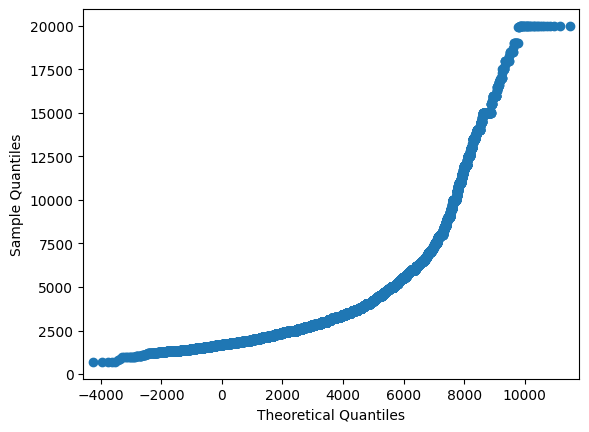

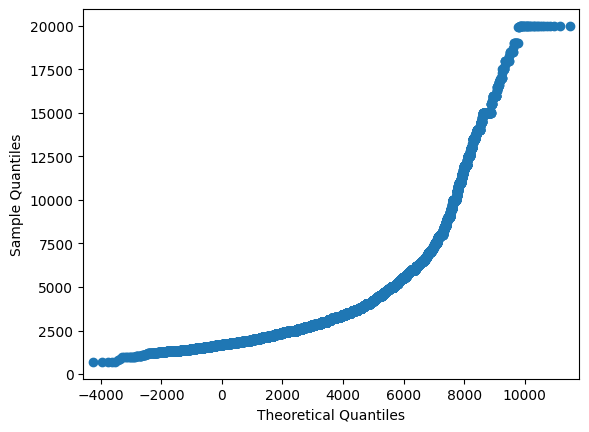

In [34]:
sm.qqplot(price, loc=price.mean(), scale=price.std())

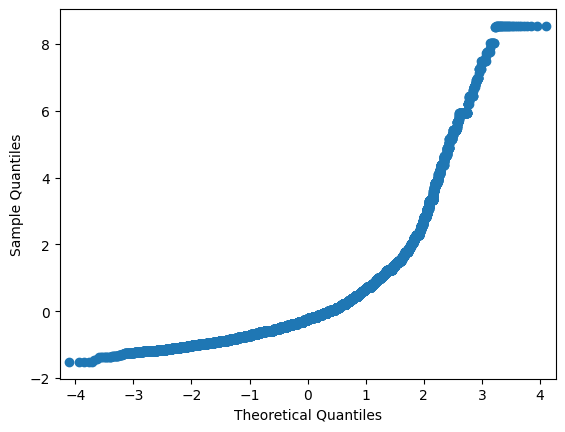

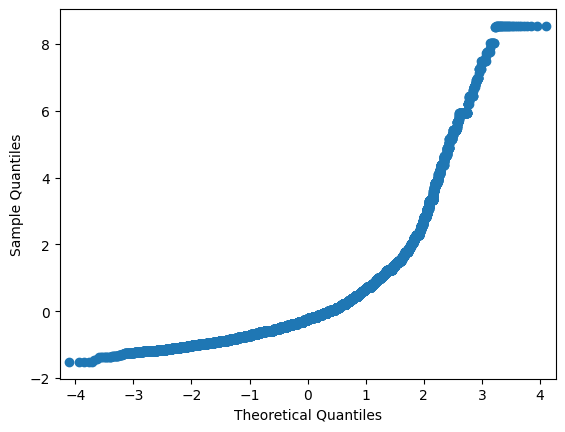

In [35]:
sm.qqplot(price_z, loc=price_z.mean(), scale=price_z.std())

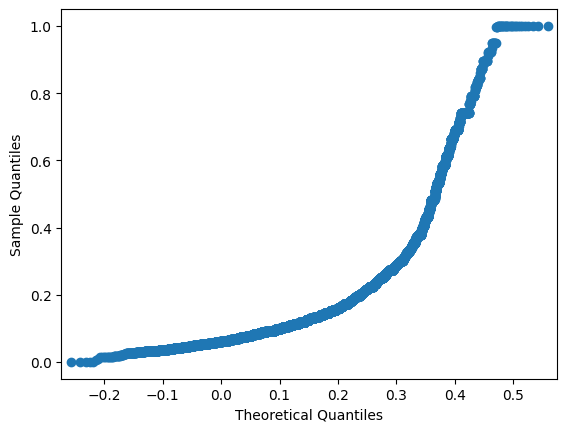

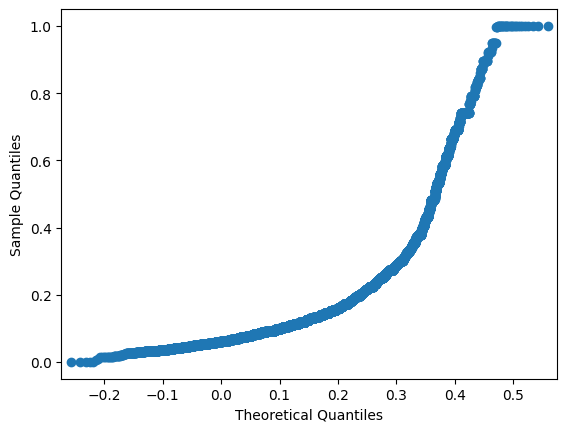

In [36]:
sm.qqplot(price_mm, loc=price_mm.mean(), scale=price_mm.std())

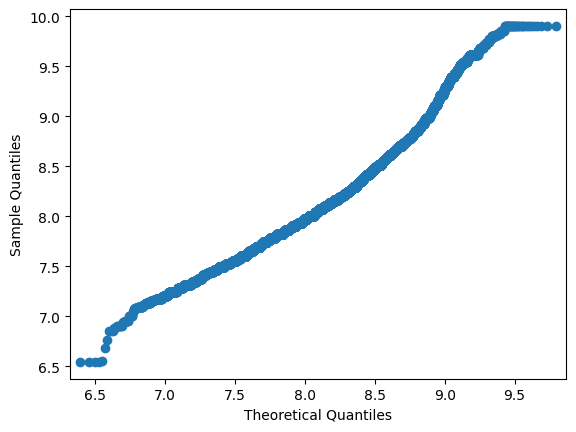

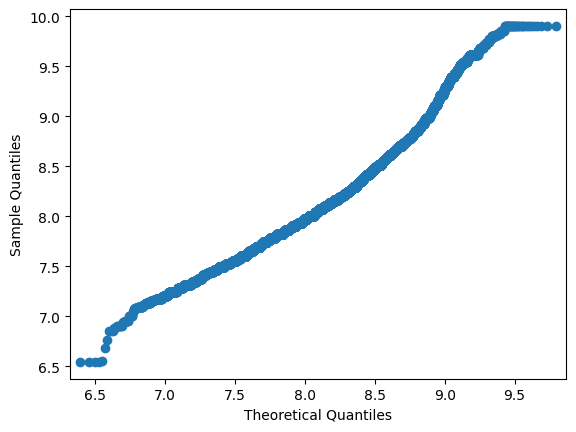

In [37]:
sm.qqplot(price_log, loc=price_log.mean(), scale=price_log.std())

## Interactions

In [38]:
rooms = df["bedrooms"].apply(lambda x: max(x, 0.5))
# Avoid division by zero; .5 is chosen more or less arbitrarily
df["price_per_bedroom"] = df["price"] / rooms

## Filling in the missing values

# Feature selection

## Statistical approaches

The most obvious candidate for removal is a feature whose value remains unchanged, i.e., it contains no information at all. If we build on this thought, it is reasonable to say that features with low variance are worse than those with high variance. So, one can consider cutting features with variance below a certain threshold.

In [39]:
from sklearn.datasets import make_classification
from sklearn.feature_selection import VarianceThreshold

x_data_generated ,y_data_generated = make_classification()
x_data_generated.shape

(100, 20)

In [40]:
# VarianceThreshold is one of the simplest feature selection techniques in scikit-learn.
#  It removes features (columns) whose variance is below a specified threshold.
VarianceThreshold(0.7).fit_transform(x_data_generated).shape

(100, 18)

In [41]:
VarianceThreshold(0.8).fit_transform(x_data_generated).shape

(100, 15)

In [42]:
VarianceThreshold(0.9).fit_transform(x_data_generated).shape

(100, 9)

There are other ways that are based on classical statistices

In [43]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

x_data_kbest = SelectKBest(
    f_classif, k=5
).fit_transform(
    x_data_generated, y_data_generated
)

x_data_varth = VarianceThreshold(0.9).fit_transform(x_data_generated)

In [44]:
logit = LogisticRegression(solver="lbfgs", random_state=17)

In [45]:
cross_val_score(
    logit, x_data_generated, y_data_generated, scoring="neg_log_loss", cv=5
).mean()

np.float64(-0.592440911540106)

In [46]:
cross_val_score(
    logit, x_data_kbest, y_data_generated, scoring="neg_log_loss", cv=5
).mean()

np.float64(-0.48961511083608544)

In [47]:
cross_val_score(
    logit, x_data_varth, y_data_generated, scoring="neg_log_loss", cv=5
).mean()

np.float64(-0.4935795912275168)

We can see that our selected features have improved the quality of the classifier. Of course, this example is purely artificial; however, it is worth using for real problems.

## Selection by modeling

Another approach is to use some baseline model for feature evaluation because the model will clearly show the importance of the features. Two types of models are usually used: some “wooden” composition such as Random Forest or a linear model with Lasso regularization so that it is prone to nullify weights of weak features. The logic is intuitive: if features are clearly useless in a simple model, there is no need to drag them to a more complex one.

In [48]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

x_data_generated, y_data_generated = make_classification()
rf = RandomForestClassifier(n_estimators=10, random_state=17)
pipe = make_pipeline(SelectFromModel(estimator=rf), logit)

print(
    cross_val_score(
        logit, x_data_generated, y_data_generated, scoring="neg_log_loss", cv=5
    ).mean()
)
print(
    cross_val_score(
        rf, x_data_generated, y_data_generated, scoring="neg_log_loss", cv=5
    ).mean()
)
print(
    cross_val_score(
        pipe, x_data_generated, y_data_generated, scoring="neg_log_loss", cv=5
    ).mean()
)

-0.47505284189181146
-1.4105079342782303
-0.4117295076352937


In [49]:
# x_data, y_data = get_data()
x_data = x_data_generated
y_data = y_data_generated

pipe1 = make_pipeline(StandardScaler(), SelectFromModel(estimator=rf), logit)

pipe2 = make_pipeline(StandardScaler(), logit)

print(
    "LR + selection: ",
    cross_val_score(pipe1, x_data, y_data, scoring="neg_log_loss", cv=5).mean(),
)
print(
    "LR: ", cross_val_score(pipe2, x_data, y_data, scoring="neg_log_loss", cv=5).mean()
)
print("RF: ", cross_val_score(rf, x_data, y_data, scoring="neg_log_loss", cv=5).mean())

LR + selection:  -0.41024174448176015
LR:  -0.4705007968414317
RF:  -1.4105079342782303


Yes. Both snippets use **model-based feature selection**, specifically `SelectFromModel`, but the pipelines are slightly different. The key idea is that **a Random Forest is used to identify the important features, and only those features are passed to the final classifier**.

Let's go through it step by step.

---

# What is `SelectFromModel`?

`SelectFromModel` is a feature selection transformer in scikit-learn.

Instead of selecting features based on correlation or statistical tests, it:

1. Fits an estimator (Random Forest in your case)
2. Looks at the feature importance values learned by the estimator
3. Removes features whose importance is below a threshold
4. Returns only the selected columns

So

```python
SelectFromModel(estimator=rf)
```

means

> "Train a Random Forest and keep only the important features."

---

# How Random Forest decides feature importance

Suppose your dataset has

```
Feature1
Feature2
Feature3
Feature4
Feature5
```

After training,

```python
rf.feature_importances_
```

might return

```
Feature1 : 0.42
Feature2 : 0.31
Feature3 : 0.18
Feature4 : 0.06
Feature5 : 0.03
```

By default,

```python
SelectFromModel
```

uses the **mean importance** as the threshold.

Mean importance

```
(0.42+0.31+0.18+0.06+0.03)/5 = 0.20
```

Therefore

```
Feature1 ✔
Feature2 ✔
Feature3 ✘
Feature4 ✘
Feature5 ✘
```

Only

```
Feature1
Feature2
```

are kept.

---

# First code

```python
rf = RandomForestClassifier(...)
pipe = make_pipeline(
        SelectFromModel(estimator=rf),
        logit
)
```

The pipeline works like this.

### Step 1

Original data

```
X
│
├── Feature1
├── Feature2
├── Feature3
├── Feature4
└── Feature5
```

---

### Step 2

`SelectFromModel`

```
Random Forest
        │
calculates feature importance
        │
drops weak features
```

Suppose it keeps

```
Feature1
Feature2
Feature3
```

Now the data becomes

```
X_selected

Feature1
Feature2
Feature3
```

---

### Step 3

The logistic regression (`logit`) is trained only on those selected features.

So the pipeline becomes

```
Raw data
      │
      ▼
Random Forest
      │
Select important features
      │
      ▼
Reduced dataset
      │
      ▼
Logistic Regression
```

---

# Why compare these three models?

You compare

```python
cross_val_score(logit,...)
```

No feature selection.

```
All features
     ↓
Logistic Regression
```

---

```python
cross_val_score(rf,...)
```

Random Forest classifier itself.

```
All features
      ↓
Random Forest
```

---

```python
cross_val_score(pipe,...)
```

Random Forest only selects features.

Logistic Regression performs the prediction.

```
All features
      ↓
Random Forest
      ↓
Feature selection
      ↓
Logistic Regression
```

This answers

> Does Logistic Regression improve if we remove unimportant features first?

---

# Second code

Now you add scaling.

```python
pipe1 = make_pipeline(
        StandardScaler(),
        SelectFromModel(estimator=rf),
        logit
)
```

Pipeline:

```
Raw data
      │
      ▼
StandardScaler
      │
      ▼
Scaled data
      │
      ▼
Random Forest Feature Selection
      │
      ▼
Selected Features
      │
      ▼
Logistic Regression
```

---

`pipe2`

```python
pipe2 = make_pipeline(
        StandardScaler(),
        logit
)
```

No feature selection.

```
Raw data
      │
StandardScaler
      │
Logistic Regression
```

So you're comparing

```
Scaling + Logistic Regression
```

vs

```
Scaling + Feature Selection + Logistic Regression
```

---

# Why StandardScaler?

Random Forest does **not** require scaling.

Logistic Regression **does**.

That's why scaling is added before Logistic Regression.

Although the Random Forest doesn't need it, it doesn't hurt because the same scaled data is passed to both steps.

---

# How feature selection happens during cross-validation

Many beginners think feature selection is done only once on the whole dataset. That would cause **data leakage**.

Using a pipeline prevents this.

Suppose

```python
cv=5
```

For each fold:

```
Fold 1

Training data
      │
      ▼
Random Forest learns feature importance
      │
      ▼
Select features
      │
      ▼
Train Logistic Regression
      │
      ▼
Predict test fold
```

Then repeat for Fold 2, Fold 3, etc.

Each fold performs feature selection **using only its training data**, which is the correct approach.

---

# Why can this improve performance?

Imagine

```
100 features

Only 10 actually matter

90 are just noise
```

Without selection

```
Logistic Regression
        ↓
tries to fit all 100 features
```

This may:

* overfit,
* increase variance,
* make coefficients less stable,
* reduce generalization.

With feature selection

```
Random Forest
      ↓
keeps only 10 useful features
      ↓
Logistic Regression
```

The logistic regression now has:

* fewer parameters,
* less noise,
* faster training,
* often better generalization (though not always).

---

# Overall workflow

```
Original Dataset
        │
        ▼
Random Forest
(compute feature importance)
        │
        ▼
Remove low-importance features
        │
        ▼
Reduced Dataset
        │
        ▼
StandardScaler (if used)
        │
        ▼
Logistic Regression
        │
        ▼
Prediction
```

So the Random Forest is **not** the final predictive model in the pipeline. It acts as a **feature selector** by ranking features according to their importance, and `SelectFromModel` uses those rankings to keep only the most informative features before passing the reduced dataset to Logistic Regression. This is a common hybrid approach because Random Forests can capture complex, non-linear relationships when estimating feature importance, while Logistic Regression often performs well on a smaller, cleaner set of features.


## Grid search

Finally, we get to the most reliable method, which is also the most computationally complex: trivial grid search.

Absolutely! Both **Exhaustive Feature Selection (EFS)** and **Sequential Feature Selection (SFS)** are **wrapper methods** for feature selection. Unlike `SelectFromModel`, which uses feature importance from a model, wrapper methods **try different subsets of features and evaluate them using a machine learning model**.

---

# 1. Exhaustive Feature Selection (EFS)

### Idea

Exhaustive Feature Selection tries **every possible combination of features** and picks the subset that gives the best cross-validation score.

Suppose you have 4 features:

```
A  B  C  D
```

EFS evaluates:

```
Size 1
-------
A
B
C
D

Size 2
-------
AB
AC
AD
BC
BD
CD

Size 3
-------
ABC
ABD
ACD
BCD

Size 4
-------
ABCD
```

It trains the model on **every subset**.

Finally, it chooses the subset with the best validation score.

---

### Number of combinations

For **n** features:

[
2^n-1
]

Examples

| Features |  Combinations |
| -------- | ------------: |
| 10       |         1,023 |
| 20       |     1,048,575 |
| 30       | 1,073,741,823 |

This grows **exponentially**, making EFS impractical for datasets with many features.

---

### Example

Using `mlxtend`:

```python
from mlxtend.feature_selection import ExhaustiveFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

lr = LogisticRegression(max_iter=1000)

efs = ExhaustiveFeatureSelector(
    lr,
    min_features=1,
    max_features=5,
    scoring='accuracy',
    cv=5
)

efs.fit(X, y)

print("Best features:", efs.best_feature_names_)
print("Best score:", efs.best_score_)
```

---

Visual idea:

```
Dataset
     │
     ▼

Try Feature1
Try Feature2
Try Feature3
Try Feature1+2
Try Feature1+3
Try Feature2+3
Try Feature1+2+3
...
```

Evaluate everything.

Choose the best.

---

# 2. Sequential Feature Selection (SFS)

Instead of checking **all** combinations, SFS searches **step by step**.

It is much faster.

---

## Forward Selection

Starts with **no features**.

```
[]
```

Try each feature individually.

```
[A]
[B]
[C]
[D]
```

Suppose A is best.

```
[A]
```

Now try adding one more.

```
[A,B]
[A,C]
[A,D]
```

Suppose

```
[A,C]
```

is best.

Now

```
[A,C]
```

Try

```
[A,C,B]
[A,C,D]
```

Continue until the desired number of features is reached.

---

Visual

```
Start
 ↓

[]

 ↓

[A]

 ↓

[A,C]

 ↓

[A,C,D]

Done
```

---

## Backward Selection

Starts with

```
[A,B,C,D]
```

Try removing one feature.

```
[B,C,D]
[A,C,D]
[A,B,D]
[A,B,C]
```

Remove the feature whose removal hurts performance the least.

Continue.

```
[A,C,D]

↓

[A,C]

↓

[A]
```

---

# Example

Using scikit-learn:

```python
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

lr = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=5,
    direction='forward',
    scoring='accuracy',
    cv=5
)

sfs.fit(X, y)

print(sfs.get_support())
```

For backward selection:

```python
sfs = SequentialFeatureSelector(
    lr,
    n_features_to_select=5,
    direction='backward',
    scoring='accuracy',
    cv=5
)
```

---

# How many models do they train?

Suppose we have **10 features** and want **5 features**.

### Exhaustive

Tests

```
10 choose 1
+
10 choose 2
+
10 choose 3
+
10 choose 4
+
10 choose 5
```

= **637** subsets.

If `cv=5`

```
637 × 5 = 3185 model fits
```

---

### Forward Sequential

Step 1

```
10 models
```

Step 2

```
9 models
```

Step 3

```
8 models
```

Step 4

```
7 models
```

Step 5

```
6 models
```

Total

```
40 models
```

With `cv=5`

```
40 × 5 = 200 model fits
```

Much faster.

---

# Comparison

| Method                                         | Strategy          | Accuracy                                      | Speed |
| ---------------------------------------------- | ----------------- | --------------------------------------------- | ----- |
| Filter methods (correlation, chi-square, etc.) | Statistical tests | Lower                                         | ⭐⭐⭐⭐⭐ |
| `SelectFromModel`                              | Model importance  | Good                                          | ⭐⭐⭐⭐  |
| Sequential Feature Selection                   | Greedy search     | Very good                                     | ⭐⭐⭐   |
| Exhaustive Feature Selection                   | Try every subset  | Best possible (for the searched subset sizes) | ⭐     |

---

# Why are they called wrapper methods?

Because they **wrap around** a machine learning model.

For every candidate subset:

```
Select subset
      │
Train model
      │
Cross Validation
      │
Score
      │
Repeat
```

The model itself is used to judge whether a feature subset is good, rather than relying on statistical criteria or feature importance alone.

---

## Why is Exhaustive Feature Selection considered the "most reliable"?

When computationally feasible, EFS is often considered the most reliable wrapper method because it evaluates **every possible feature subset** within the specified size range. It doesn't rely on greedy decisions, so it won't miss a better combination just because an earlier choice looked good locally.

Sequential methods are **greedy**. For example, Forward Selection might pick feature `A` first because it performs best alone, but the truly optimal subset could be `{B, C}`. Since `B` wasn't selected in the first step, the algorithm may never discover that better combination. EFS, by testing all subsets, would find it.

So the trade-off is:

* **Exhaustive Feature Selection:** Highest chance of finding the optimal subset, but computationally expensive.
* **Sequential Feature Selection:** Much faster and usually performs well, but it may miss the global optimum because of its greedy search strategy.
